# LeetCode #15: 3Sum

https://leetcode.com/problems/3sum/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^3)$ | $O(n)$ |
| **Optimal: Sorting + Two Pointers** ★ | $O(n^2)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Check all combinations of three indices with three nested loops. Store results in a set to deduplicate. Cubic time makes it infeasible beyond a few hundred elements.

### Optimal: Sorting + Two Pointers ★
Sort the array, then fix each element at index `i` and use two inward-moving pointers to find the pair that sums to `-nums[i]`. Skip duplicate values at each pointer position to guarantee unique triplets without a set.

**Why this is better than Brute Force:** Sorting reduces the triple scan to a single pass per anchor — $O(n^2)$ vs $O(n^3)$ — and pointer skipping eliminates duplicates in-place with no extra data structure.

**Constraints:**
* 3 <= nums.length <= 3000
* -10^5 <= nums[i] <= 10^5

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<IList<int>> ThreeSum(int[] nums) {
        var result = new List<IList<int>>();
        Array.Sort(nums);
        for (int i = 0; i < nums.Length - 2; i++) {
            // Skip duplicate anchor values to avoid duplicate triplets
            if (i > 0 && nums[i] == nums[i - 1]) continue;
            int left = i + 1, right = nums.Length - 1;
            while (left < right) {
                int sum = nums[i] + nums[left] + nums[right];
                if (sum == 0) {
                    result.Add(new List<int> { nums[i], nums[left], nums[right] });
                    // Advance past duplicates on both sides before converging
                    while (left < right && nums[left] == nums[left + 1]) left++;
                    while (left < right && nums[right] == nums[right - 1]) right--;
                    left++;
                    right--;
                } else if (sum < 0) {
                    left++;
                } else {
                    right--;
                }
            }
        }
        return result;
    }
}

### Python

In [ ]:
class Solution:
    def threeSum(self, nums: list[int]) -> list[list[int]]:
        result = []
        nums.sort()
        for i in range(len(nums) - 2):
            # Skip duplicate anchor values to avoid duplicate triplets
            if i > 0 and nums[i] == nums[i - 1]:
                continue
            left, right = i + 1, len(nums) - 1
            while left < right:
                total = nums[i] + nums[left] + nums[right]
                if total == 0:
                    result.append([nums[i], nums[left], nums[right]])
                    # Advance past duplicates on both sides before converging
                    while left < right and nums[left] == nums[left + 1]:
                        left += 1
                    while left < right and nums[right] == nums[right - 1]:
                        right -= 1
                    left += 1
                    right -= 1
                elif total < 0:
                    left += 1
                else:
                    right -= 1
        return result

### Go

In [ ]:
import "sort"

func threeSum(nums []int) [][]int {
    sort.Ints(nums)
    result := [][]int{}
    for i := 0; i < len(nums)-2; i++ {
        // Skip duplicate anchor values to avoid duplicate triplets
        if i > 0 && nums[i] == nums[i-1] {
            continue
        }
        left, right := i+1, len(nums)-1
        for left < right {
            sum := nums[i] + nums[left] + nums[right]
            if sum == 0 {
                result = append(result, []int{nums[i], nums[left], nums[right]})
                // Advance past duplicates on both sides before converging
                for left < right && nums[left] == nums[left+1] {
                    left++
                }
                for left < right && nums[right] == nums[right-1] {
                    right--
                }
                left++
                right--
            } else if sum < 0 {
                left++
            } else {
                right--
            }
        }
    }
    return result
}

### Rust

In [ ]:
pub fn three_sum(nums: Vec<i32>) -> Vec<Vec<i32>> {
    let mut nums = nums;
    nums.sort_unstable();
    let mut result = vec![];
    let n = nums.len();
    for i in 0..n.saturating_sub(2) {
        // Skip duplicate anchor values to avoid duplicate triplets
        if i > 0 && nums[i] == nums[i - 1] {
            continue;
        }
        let (mut left, mut right) = (i + 1, n - 1);
        while left < right {
            let sum = nums[i] + nums[left] + nums[right];
            if sum == 0 {
                result.push(vec![nums[i], nums[left], nums[right]]);
                // Advance past duplicates on both sides before converging
                while left < right && nums[left] == nums[left + 1] { left += 1; }
                while left < right && nums[right] == nums[right - 1] { right -= 1; }
                left += 1;
                right -= 1;
            } else if sum < 0 {
                left += 1;
            } else {
                right -= 1;
            }
        }
    }
    result
}

## Example Scenarios

**1. Common Case**
**Input:** `nums = [-1, 0, 1, 2, -1, -4]`
Sorted to `[-4,-1,-1,0,1,2]`; anchor at index 1 (−1) finds `[-1,-1,2]` then `[-1,0,1]` before pointers cross; index 2 is skipped as a duplicate anchor. Output: `[[-1,-1,2],[-1,0,1]]`.

**2. Slightly Complex**
**Input:** `nums = [-2, 0, 1, 1, 2]`
Already sorted; anchor −2 finds pair (0, 2) first, then pair (1, 1) — the duplicate-skip loop advances the right pointer past the repeated 1 to prevent a second `[-2,1,1]` from being emitted. Output: `[[-2,0,2],[-2,1,1]]`.

**3. Edge Case: Time Factor**
**Input:** `nums = [0, 0, 0, 0, 0]`
Match fires instantly at i=0, but the duplicate-skip loops must scan the entire remaining array — $O(n)$ work per anchor just to advance past the repeated zeros — and every subsequent i is skipped as a duplicate of index 0. Worst case for total iterations despite just one result.

**4. Edge Case: Space Factor**
**Input:** `nums = [-4, -2, -1, 0, 1, 2, 4]`
Each distinct anchor produces a unique valid triplet: `[-4,0,4]`, `[-2,0,2]`, `[-1,0,1]`. Output size grows with the number of valid zero-sum combinations — the sole driver of space complexity $O(k)$ where $k$ is the triplet count.

**5. Almost-Impossible but Plausible**
**Input:** `nums = [-100000, 50000, 50000]`
Minimum valid length (3); values sit at the $\pm 10^5$ constraint boundary. Sort is a no-op; i=0 pins to −100000, both pointers land on 50000, sum is exactly 0 on the very first check — no iteration needed. Output: `[[-100000,50000,50000]]`.

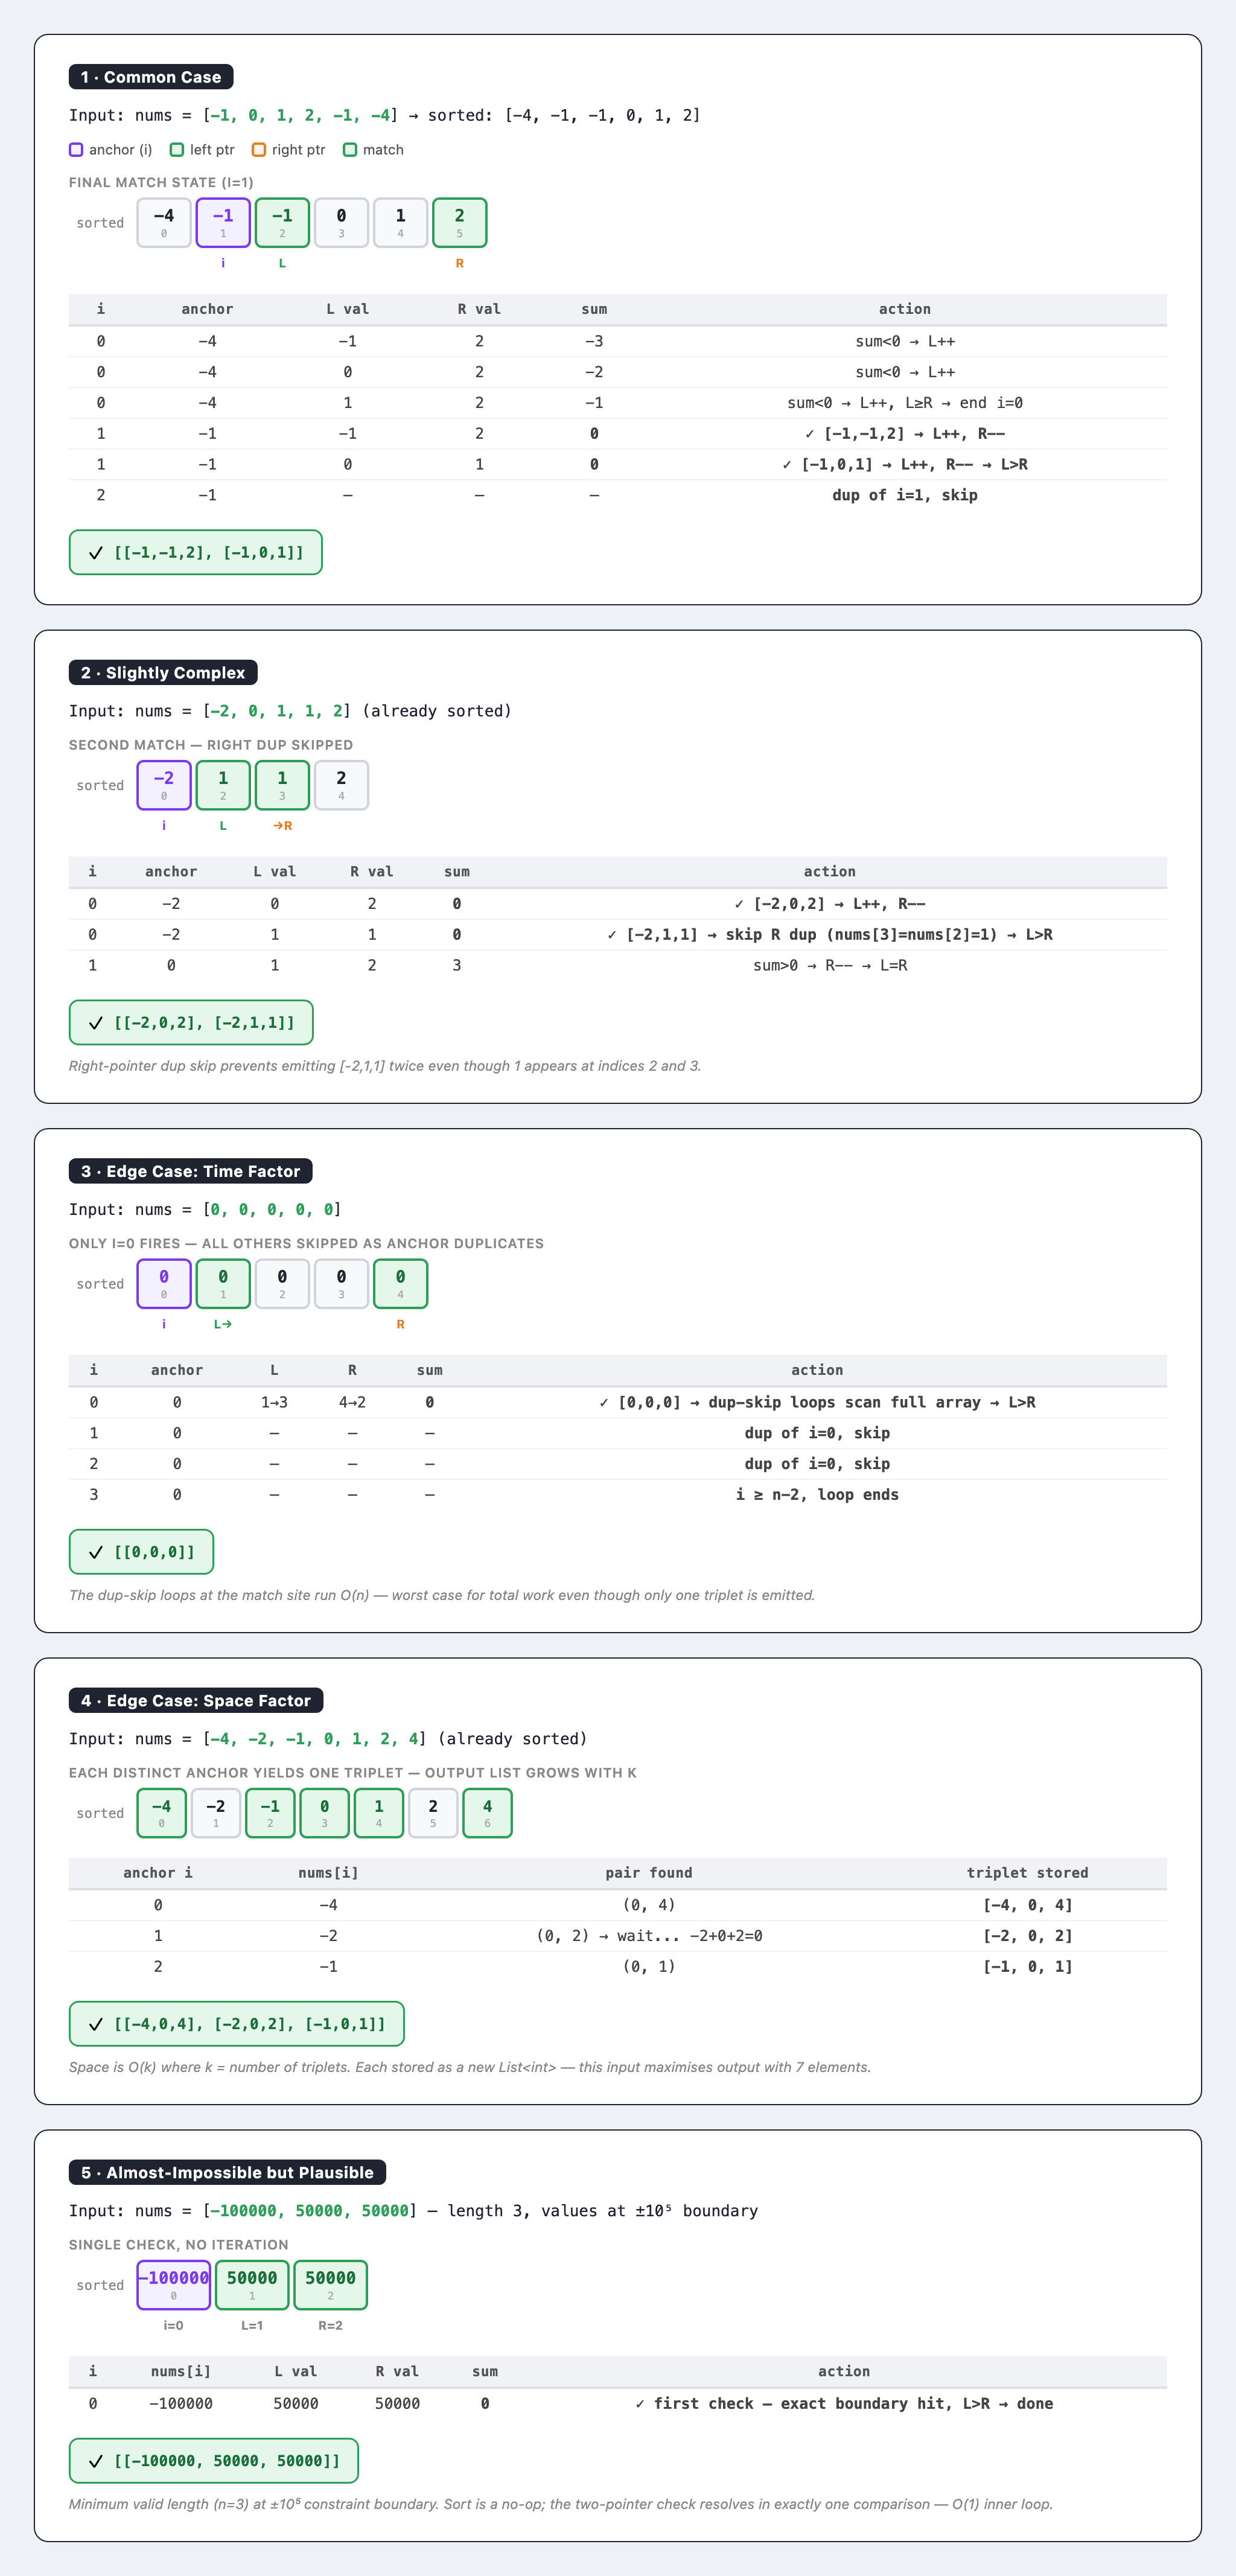